# Synthetic Heat-Diffusion Data QC

Initial analysis notebook for the finite-difference synthetic dataset.

Goals:
- Verify file presence, shapes, dtypes, and finite values.
- Inspect alpha, heater, initial-temperature, and final-temperature distributions.
- Visualize representative in-distribution and OOD samples.
- Run a simple physics sanity check for the heat equation with zero-flux boundaries.
- Confirm OOD heater cases are visibly different from centered training heaters.

In [11]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# If this notebook is opened from the repo root, this is already correct.
# If it is opened from notebooks/, the fallback below fixes paths.
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

split_names = ["train", "val", "test", "ood_corner", "ood_multi"]
print(f"Repo root: {ROOT}")
print(f"Data dir:  {DATA_DIR}")

Repo root: /Users/vicki/digital-twin-heat-surrogate
Data dir:  /Users/vicki/digital-twin-heat-surrogate/data


## Load Metadata and Splits

In [12]:
metadata_path = DATA_DIR / "metadata.json"
with metadata_path.open("r", encoding="utf-8") as f:
    metadata = json.load(f)

metadata

{'out_dir': 'data',
 'figure_dir': 'figures',
 'grid_size': 32,
 'steps': 100,
 'dt': 0.001,
 'alpha_min': 0.02,
 'alpha_max': 0.08,
 'n_train': 1000,
 'n_val': 200,
 'n_test': 200,
 'n_ood': 200,
 'seed': 0,
 'dx': 0.03225806451612903,
 'equation': 'du/dt = alpha * laplacian(u) + q(x,y)',
 'boundary_condition': 'zero-flux Neumann'}

In [13]:
def load_split(name):
    path = DATA_DIR / f"{name}.npz"
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run: python3 src/simulate.py")
    data = np.load(path)
    return {
        "path": path,
        "X": data["X"],
        "Y": data["Y"],
        "alpha": data["alpha"],
        "heater_mode": str(data["heater_mode"]),
    }

splits = {name: load_split(name) for name in split_names}
[(name, s["X"].shape, s["Y"].shape, s["heater_mode"]) for name, s in splits.items()]

[('train', (1000, 3, 32, 32), (1000, 1, 32, 32), 'center'),
 ('val', (200, 3, 32, 32), (200, 1, 32, 32), 'center'),
 ('test', (200, 3, 32, 32), (200, 1, 32, 32), 'center'),
 ('ood_corner', (200, 3, 32, 32), (200, 1, 32, 32), 'corner'),
 ('ood_multi', (200, 3, 32, 32), (200, 1, 32, 32), 'multi')]

## Basic Integrity Checks

In [14]:
def summarize_split(name, split):
    X, Y, alpha = split["X"], split["Y"], split["alpha"]
    initial = X[:, 0]
    heater = X[:, 1]
    alpha_channel = X[:, 2]
    final = Y[:, 0]
    alpha_channel_error = np.abs(alpha_channel - alpha[:, None, None]).max()
    return {
        "split": name,
        "mode": split["heater_mode"],
        "X_shape": X.shape,
        "Y_shape": Y.shape,
        "dtype": str(X.dtype),
        "finite": bool(np.isfinite(X).all() and np.isfinite(Y).all()),
        "alpha_min": float(alpha.min()),
        "alpha_max": float(alpha.max()),
        "alpha_channel_error": float(alpha_channel_error),
        "initial_range": (float(initial.min()), float(initial.max())),
        "heater_range": (float(heater.min()), float(heater.max())),
        "final_range": (float(final.min()), float(final.max())),
    }

summaries = [summarize_split(name, split) for name, split in splits.items()]
for row in summaries:
    print(row)

# Hard checks: these should pass before training anything.
grid_size = metadata["grid_size"]
alpha_min = metadata["alpha_min"]
alpha_max = metadata["alpha_max"]
for name, split in splits.items():
    X, Y, alpha = split["X"], split["Y"], split["alpha"]
    assert X.ndim == 4 and X.shape[1:] == (3, grid_size, grid_size), name
    assert Y.ndim == 4 and Y.shape[1:] == (1, grid_size, grid_size), name
    assert X.dtype == np.float32 and Y.dtype == np.float32, name
    assert np.isfinite(X).all() and np.isfinite(Y).all(), name
    assert np.all(alpha >= alpha_min) and np.all(alpha <= alpha_max), name
    assert np.allclose(X[:, 2], alpha[:, None, None]), name

print("All integrity checks passed.")

{'split': 'train', 'mode': 'center', 'X_shape': (1000, 3, 32, 32), 'Y_shape': (1000, 1, 32, 32), 'dtype': 'float32', 'finite': True, 'alpha_min': 0.020036369562149048, 'alpha_max': 0.07998020946979523, 'alpha_channel_error': 0.0, 'initial_range': (0.0, 1.6926690340042114), 'heater_range': (0.0, 5.932153224945068), 'final_range': (0.0006832614890299737, 1.085797667503357)}
{'split': 'val', 'mode': 'center', 'X_shape': (200, 3, 32, 32), 'Y_shape': (200, 1, 32, 32), 'dtype': 'float32', 'finite': True, 'alpha_min': 0.020450077950954437, 'alpha_max': 0.07996132224798203, 'alpha_channel_error': 0.0, 'initial_range': (0.0, 1.4628441333770752), 'heater_range': (0.0, 5.9593658447265625), 'final_range': (0.001012145890854299, 1.1038707494735718)}
{'split': 'test', 'mode': 'center', 'X_shape': (200, 3, 32, 32), 'Y_shape': (200, 1, 32, 32), 'dtype': 'float32', 'finite': True, 'alpha_min': 0.02011203020811081, 'alpha_max': 0.0797915831208229, 'alpha_channel_error': 0.0, 'initial_range': (0.0, 1.422

## Distribution Checks

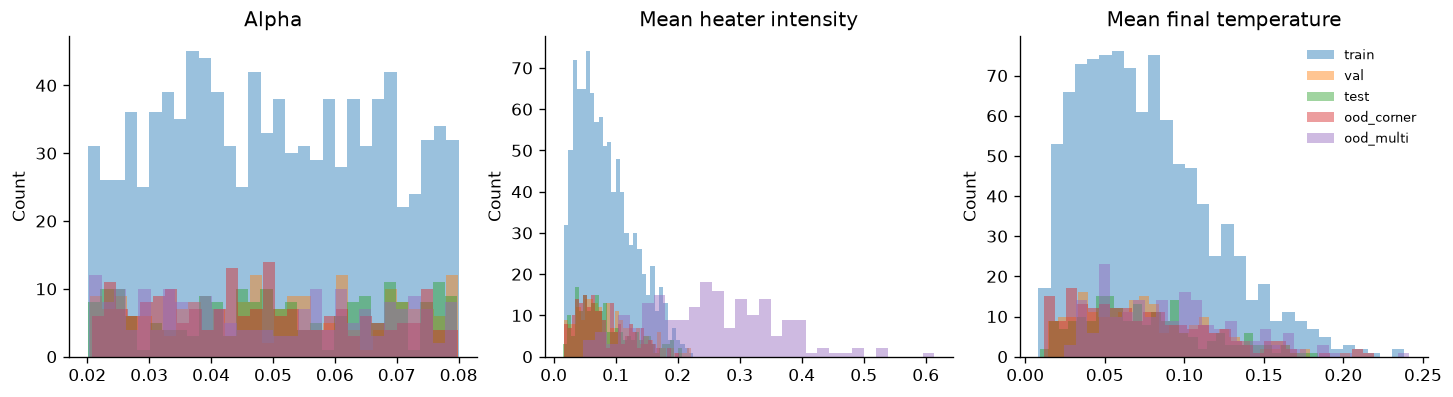

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)

for name, split in splits.items():
    X, Y, alpha = split["X"], split["Y"], split["alpha"]
    axes[0].hist(alpha, bins=30, alpha=0.45, label=name)
    axes[1].hist(X[:, 1].mean(axis=(1, 2)), bins=30, alpha=0.45, label=name)
    axes[2].hist(Y[:, 0].mean(axis=(1, 2)), bins=30, alpha=0.45, label=name)

axes[0].set_title("Alpha")
axes[1].set_title("Mean heater intensity")
axes[2].set_title("Mean final temperature")
for ax in axes:
    ax.set_ylabel("Count")
axes[2].legend(frameon=False, fontsize=8)
plt.show()

In [16]:
def per_sample_stats(split):
    X, Y = split["X"], split["Y"]
    return {
        "initial_mean": X[:, 0].mean(axis=(1, 2)),
        "initial_max": X[:, 0].max(axis=(1, 2)),
        "heater_mean": X[:, 1].mean(axis=(1, 2)),
        "heater_max": X[:, 1].max(axis=(1, 2)),
        "final_mean": Y[:, 0].mean(axis=(1, 2)),
        "final_max": Y[:, 0].max(axis=(1, 2)),
    }

for name, split in splits.items():
    stats = per_sample_stats(split)
    print(f"\n{name}")
    for key, values in stats.items():
        print(f"  {key:>13s}: mean={values.mean():.4f}, std={values.std():.4f}, min={values.min():.4f}, max={values.max():.4f}")


train
   initial_mean: mean=0.0674, std=0.0414, min=0.0054, max=0.2317
    initial_max: mean=0.6230, std=0.2477, min=0.1050, max=1.6927
    heater_mean: mean=0.0831, std=0.0440, min=0.0166, max=0.2253
     heater_max: mean=3.9495, std=1.1380, min=1.8345, max=5.9322
     final_mean: mean=0.0757, std=0.0416, min=0.0083, max=0.2382
      final_max: mean=0.4200, std=0.1800, min=0.0569, max=1.0858

val
   initial_mean: mean=0.0665, std=0.0388, min=0.0067, max=0.1995
    initial_max: mean=0.6349, std=0.2518, min=0.1517, max=1.4628
    heater_mean: mean=0.0876, std=0.0462, min=0.0161, max=0.2216
     heater_max: mean=3.8693, std=1.1209, min=1.9463, max=5.9594
     final_mean: mean=0.0753, std=0.0396, min=0.0142, max=0.2044
      final_max: mean=0.4194, std=0.1838, min=0.0993, max=1.1039

test
   initial_mean: mean=0.0665, std=0.0393, min=0.0064, max=0.1765
    initial_max: mean=0.6403, std=0.2305, min=0.1258, max=1.4224
    heater_mean: mean=0.0846, std=0.0456, min=0.0155, max=0.2074
     he

## Representative Samples

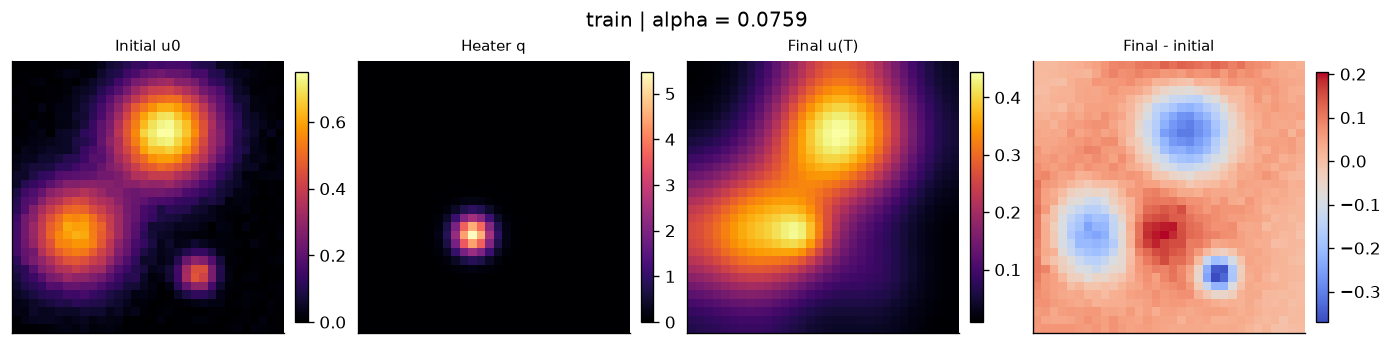

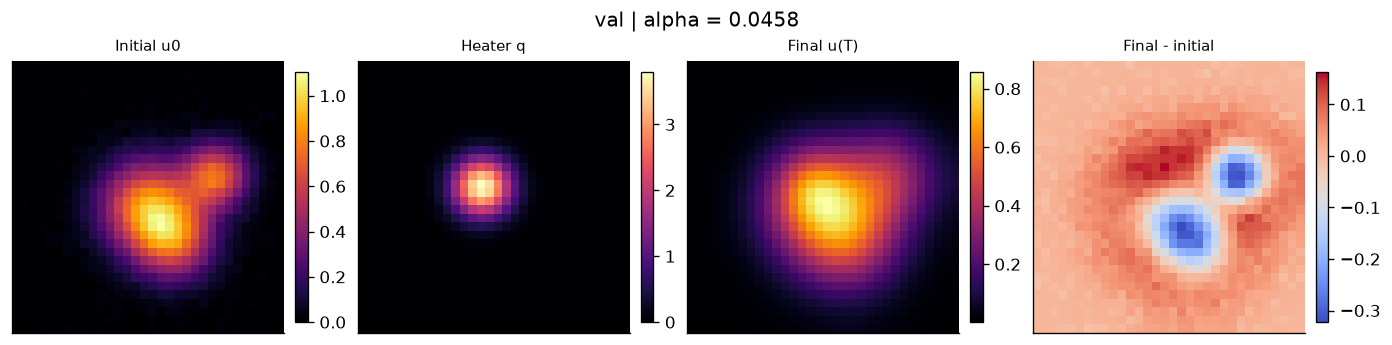

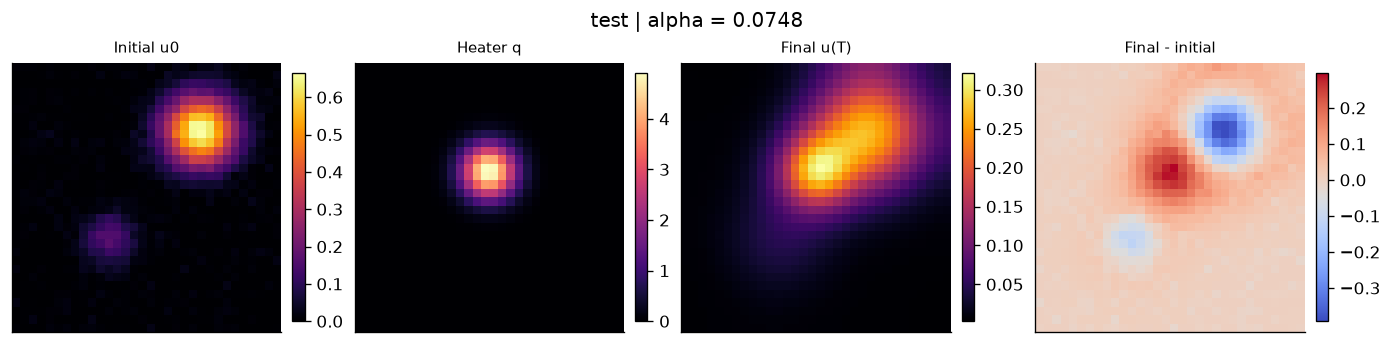

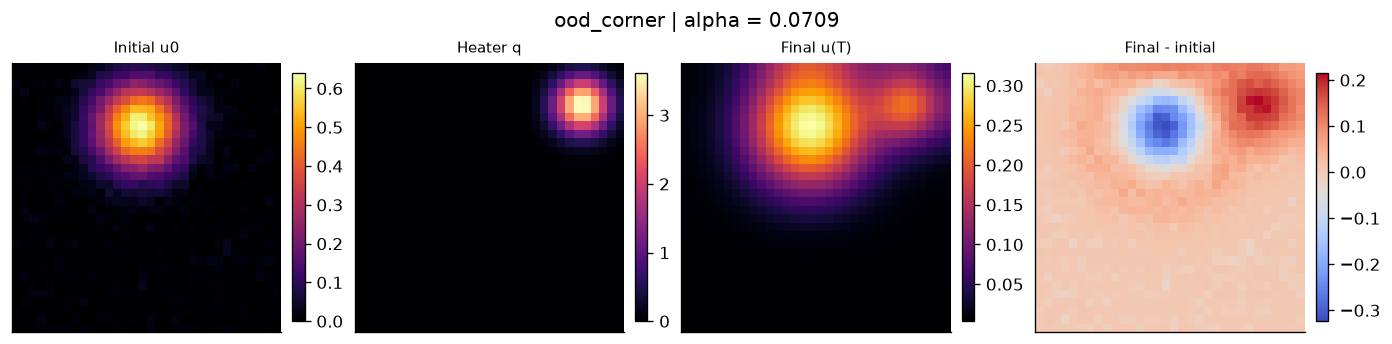

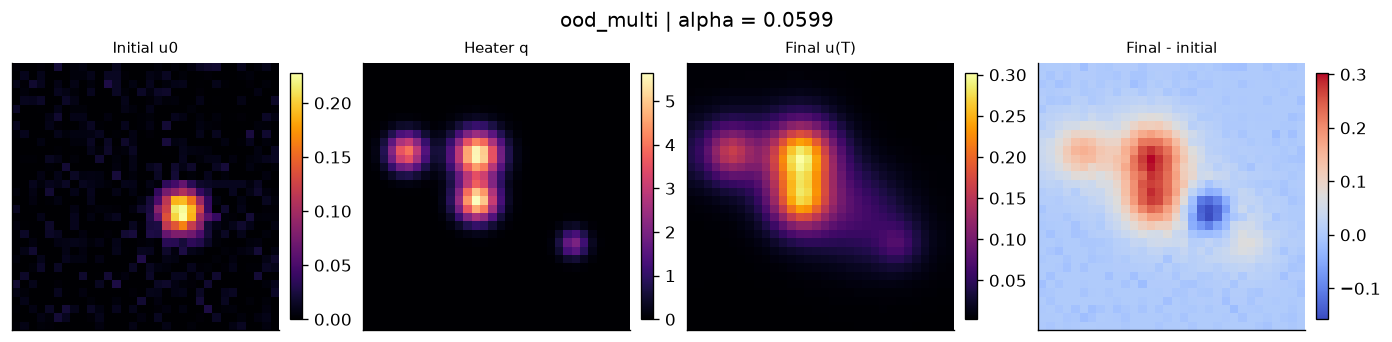

In [17]:
def plot_sample(split, idx=0, title_prefix=""):
    X, Y, alpha = split["X"], split["Y"], split["alpha"]
    fields = [X[idx, 0], X[idx, 1], Y[idx, 0], Y[idx, 0] - X[idx, 0]]
    titles = ["Initial u0", "Heater q", "Final u(T)", "Final - initial"]
    cmaps = ["inferno", "magma", "inferno", "coolwarm"]
    fig, axes = plt.subplots(1, 4, figsize=(11.5, 2.8), constrained_layout=True)
    fig.suptitle(f"{title_prefix} | alpha = {alpha[idx]:.4f}", y=1.05)
    for ax, field, title, cmap in zip(axes, fields, titles, cmaps):
        im = ax.imshow(field, origin="lower", cmap=cmap)
        ax.set_title(title, fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return fig

for name in split_names:
    plot_sample(splits[name], idx=0, title_prefix=name)
    plt.show()

## OOD Heater Location Check

For the planned reliability story, centered training heaters should cluster near the middle, while `ood_corner` should cluster near corners and `ood_multi` should spread more broadly.

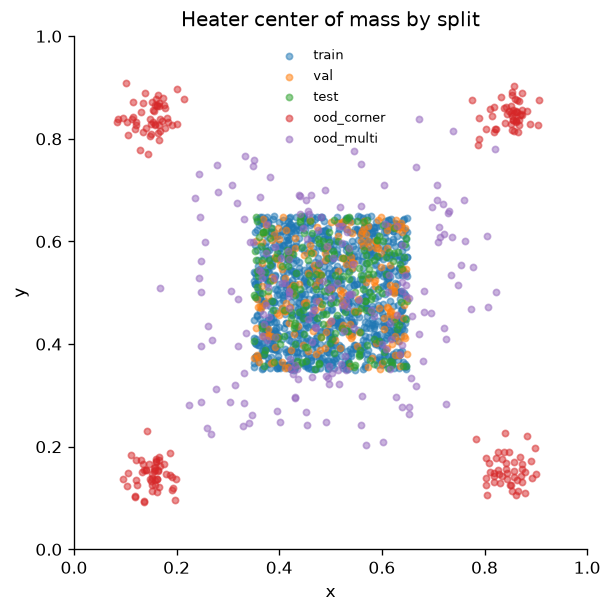

In [18]:
def heater_center_of_mass(heater_batch):
    n, h, w = heater_batch.shape
    yy, xx = np.meshgrid(np.linspace(0, 1, h), np.linspace(0, 1, w), indexing="ij")
    mass = heater_batch.sum(axis=(1, 2)) + 1e-12
    cx = (heater_batch * xx[None]).sum(axis=(1, 2)) / mass
    cy = (heater_batch * yy[None]).sum(axis=(1, 2)) / mass
    return cx, cy

fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
for name, split in splits.items():
    cx, cy = heater_center_of_mass(split["X"][:, 1])
    ax.scatter(cx, cy, s=14, alpha=0.5, label=name)
ax.set_title("Heater center of mass by split")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.legend(frameon=False, fontsize=8)
plt.show()

## Physics Sanity Check

With zero-flux Neumann boundaries, the diffusion term should not change the spatial mean. The source term should increase the mean by roughly:

`steps * dt * mean(source)`

Small numerical differences are expected from finite precision.

     train: mean abs balance error = 3.802e-09, max abs = 2.794e-08
       val: mean abs balance error = 3.804e-09, max abs = 2.235e-08
      test: mean abs balance error = 3.644e-09, max abs = 2.095e-08
ood_corner: mean abs balance error = 3.742e-09, max abs = 2.328e-08
 ood_multi: mean abs balance error = 4.258e-09, max abs = 1.676e-08


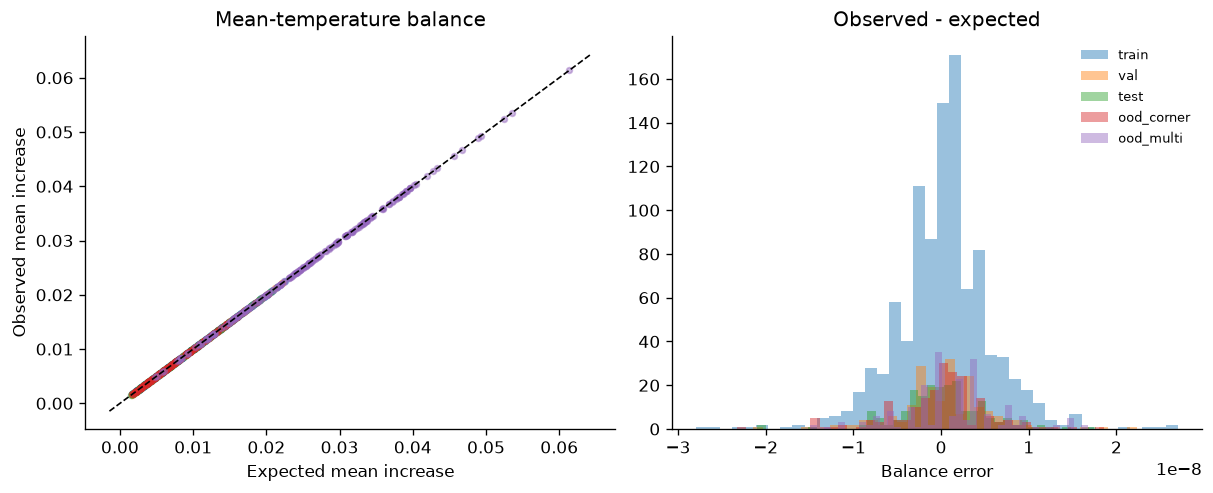

In [19]:
def mean_balance_error(split):
    X, Y = split["X"], split["Y"]
    steps = metadata["steps"]
    dt = metadata["dt"]
    observed_delta = Y[:, 0].mean(axis=(1, 2)) - X[:, 0].mean(axis=(1, 2))
    expected_delta = steps * dt * X[:, 1].mean(axis=(1, 2))
    return observed_delta, expected_delta, observed_delta - expected_delta

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for name, split in splits.items():
    observed, expected, err = mean_balance_error(split)
    axes[0].scatter(expected, observed, s=12, alpha=0.45, label=name)
    axes[1].hist(err, bins=40, alpha=0.45, label=name)
    print(f"{name:>10s}: mean abs balance error = {np.abs(err).mean():.3e}, max abs = {np.abs(err).max():.3e}")

lo, hi = axes[0].get_xlim()
axes[0].plot([lo, hi], [lo, hi], color="black", lw=1, linestyle="--")
axes[0].set_title("Mean-temperature balance")
axes[0].set_xlabel("Expected mean increase")
axes[0].set_ylabel("Observed mean increase")
axes[1].set_title("Observed - expected")
axes[1].set_xlabel("Balance error")
axes[1].legend(frameon=False, fontsize=8)
plt.show()

## Save a Clean QC Figure for README Drafting

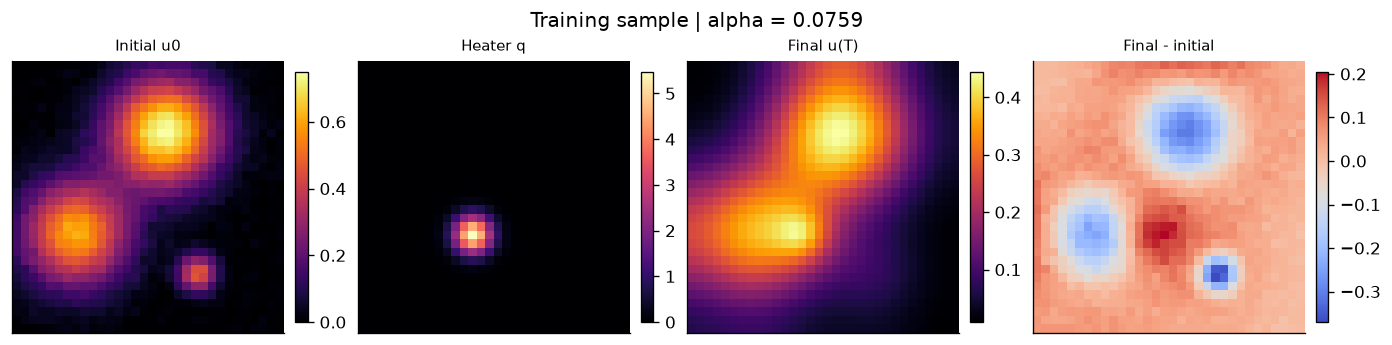

Saved /Users/vicki/digital-twin-heat-surrogate/figures/synthetic_data_qc_sample.png


In [20]:
fig = plot_sample(splits["train"], idx=0, title_prefix="Training sample")
out_path = FIGURE_DIR / "synthetic_data_qc_sample.png"
fig.savefig(out_path, bbox_inches="tight")
plt.show()
print(f"Saved {out_path}")

## Quick Verdict

Things should look healthy if:
- All integrity checks pass.
- Alpha is within the configured range and the alpha channel matches the scalar alpha.
- Initial/final/source fields are finite and smooth.
- Final temperature is warmer near heater regions but not numerically explosive.
- The mean-temperature balance plot lies close to the diagonal.
- OOD heater centers differ from training heater centers.